# Analisis exploratorio de viajes de taxi de Nueva York (2024 y 2026)

Este notebook responde las preguntas de analisis del Ejercicio 4 usando DuckDB sobre la tabla `trips`
(`data/processed/taxi.duckdb`), creada por `scripts/create_database.py` a partir de los Parquet de la NYC TLC.
Las mismas consultas, con su explicacion, estan en `sql/analysis.sql`.

**Preguntas**

1. Cuantos viajes se realizan por mes?
2. Cual es la distancia promedio? 3. Cual es la tarifa promedio?
4. Que diferencias hay entre taxis amarillos y verdes?
5. Como varia la actividad por hora y dia de la semana?
6. Que formas de pago se usan mas?
7. Que valores atipicos aparecen?
8. Que hallazgos relevantes se observan?

**Dos precauciones.** (a) 2026 solo tiene enero a agosto (la TLC aun no publica el resto), por eso las
comparaciones anuales usan `month <= 8` o proporciones. (b) Los promedios usan solo *viajes validos*:
`0 < distancia < 100` millas, `0 < tarifa < 1000` USD y `0 < duracion < 24 h`, porque los extremos son errores de captura
(ver `docs/data_quality.md`).

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RUTA_DB = next(p for p in (Path("data/processed/taxi.duckdb"), Path("../data/processed/taxi.duckdb")) if p.exists())
con = duckdb.connect(str(RUTA_DB), read_only=True)

COLOR = {"yellow": "#E0A100", "green": "#2E8B57"}
VALIDO = "trip_distance > 0 AND trip_distance < 100 AND fare_amount > 0 AND fare_amount < 1000 AND duration_minutes > 0 AND duration_minutes < 1440"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

def q(sql):
    return con.execute(sql).fetchdf()

q("SELECT taxi_type, year, count(*) AS viajes, min(month) AS mes_min, max(month) AS mes_max FROM trips GROUP BY ALL ORDER BY ALL")

,taxi_type,year,viajes,mes_min,mes_max
0,green,2024,660218,1,12
1,green,2026,337114,1,8
2,yellow,2024,41169720,1,12
3,yellow,2026,29703355,1,8


## P1. Viajes por mes

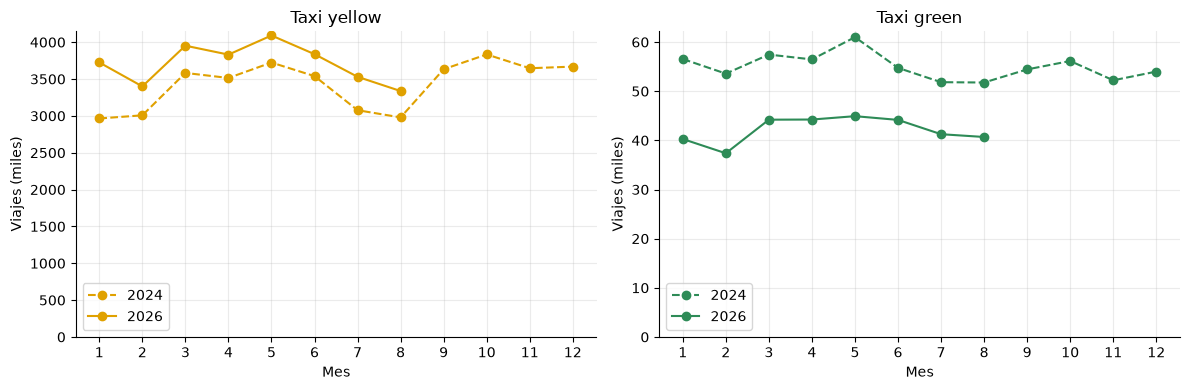

,taxi_type,year,viajes_ene_ago,cambio_vs_2024_pct
0,green,2024,443415,NaN
1,green,2026,337114,-24.0
2,yellow,2024,26388179,NaN
3,yellow,2026,29703355,12.6


In [2]:
mensual = q("SELECT taxi_type, year, month, count(*) AS viajes FROM trips GROUP BY ALL ORDER BY ALL")
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for eje, tipo in zip(ejes, ("yellow", "green")):
    for anio, estilo in ((2024, "--"), (2026, "-")):
        d = mensual[(mensual.taxi_type == tipo) & (mensual.year == anio)]
        eje.plot(d.month, d.viajes / 1000, estilo, marker="o", color=COLOR[tipo], label=str(anio))
    eje.set_title(f"Taxi {tipo}"); eje.set_xlabel("Mes"); eje.set_ylabel("Viajes (miles)")
    eje.set_xticks(range(1, 13)); eje.set_ylim(bottom=0); eje.legend()
plt.tight_layout(); plt.show()

comparable = q("SELECT taxi_type, year, count(*) AS viajes_ene_ago FROM trips WHERE month <= 8 GROUP BY ALL ORDER BY ALL")
comparable["cambio_vs_2024_pct"] = comparable.groupby("taxi_type").viajes_ene_ago.pct_change().mul(100).round(1)
comparable

**Interpretacion.** Yellow mueve unos 3.0 a 4.1 millones de viajes al mes y green entre 37 mil y 61 mil: green es
aproximadamente el 1.4 % del volumen. Hay estacionalidad (marzo, mayo y octubre fuertes; enero, febrero, julio y agosto mas bajos en 2024).
Comparando solo enero a agosto, yellow crece **12.6 %** de 2024 a 2026 (26.4 M a 29.7 M viajes) mientras green cae **24.0 %** (443 mil a 337 mil).

In [3]:
resumen = q(f'''
SELECT taxi_type, year, count(*) AS viajes_validos,
       round(avg(trip_distance), 2) AS dist_prom_millas, round(median(trip_distance), 2) AS dist_mediana,
       round(avg(fare_amount), 2) AS tarifa_prom_usd, round(median(fare_amount), 2) AS tarifa_mediana,
       round(avg(total_amount), 2) AS total_prom_usd, round(avg(duration_minutes), 1) AS duracion_prom_min
FROM trips WHERE {VALIDO} GROUP BY ALL ORDER BY ALL''')
resumen

,taxi_type,year,viajes_validos,dist_prom_millas,dist_mediana,tarifa_prom_usd,tarifa_mediana,total_prom_usd,duracion_prom_min
0,green,2024,623736,2.95,1.97,18.17,13.5,24.22,19.9
1,green,2026,319447,3.31,2.12,17.16,13.5,25.48,21.1
2,yellow,2024,39702640,3.42,1.80,19.81,14.2,28.64,17.6
3,yellow,2026,28229185,3.52,1.93,21.30,15.6,30.25,17.9


## P2 y P3. Distancia y tarifa promedio

**Interpretacion.** El viaje yellow promedio mide 3.4 a 3.5 millas y cuesta 19.8 USD en 2024 y 21.3 USD en 2026 (+7.5 %).
La mediana (1.8 a 1.9 millas, 14.2 a 15.6 USD) es mucho menor que el promedio: la distribucion tiene cola larga por los viajes
a aeropuertos y fuera de la ciudad, asi que **la mediana describe mejor el viaje tipico**. En green, la distancia sube (2.95 a 3.31 millas) pero la tarifa promedio baja (18.2 a 17.2 USD).

## P4. Yellow vs. green

In [4]:
comparacion = q(f'''
SELECT taxi_type, count(*) AS viajes_validos,
       round(avg(trip_distance), 2) AS distancia_prom, round(avg(fare_amount), 2) AS tarifa_prom,
       round(avg(tip_amount), 2) AS propina_prom, round(100 * sum(tip_amount) / sum(fare_amount), 1) AS propina_pct_tarifa,
       round(avg(duration_minutes), 1) AS duracion_min, round(avg(passenger_count), 2) AS pasajeros_prom,
       round(avg(trip_distance / (duration_minutes / 60.0)), 1) AS velocidad_mph
FROM trips WHERE {VALIDO} GROUP BY ALL ORDER BY ALL''')
display(comparacion)
zonas = q('''
SELECT taxi_type, pu_location_id AS zona_origen, count(*) AS viajes FROM trips GROUP BY taxi_type, pu_location_id
QUALIFY row_number() OVER (PARTITION BY taxi_type ORDER BY count(*) DESC) <= 5 ORDER BY taxi_type, viajes DESC''')
zonas

,taxi_type,viajes_validos,distancia_prom,tarifa_prom,propina_prom,propina_pct_tarifa,duracion_min,pasajeros_prom,velocidad_mph
0,green,943183,3.07,17.82,2.65,14.9,20.3,1.32,15.6
1,yellow,67931825,3.46,20.43,3.18,15.5,17.8,1.30,11.2


,taxi_type,zona_origen,viajes
0,green,74,238187
1,green,75,134396
2,green,95,48908
3,green,166,46100
4,green,43,45902
5,yellow,237,3222517
6,yellow,132,3171599
7,yellow,161,3137541
8,yellow,236,2898392
9,yellow,162,2320858


**Interpretacion.** Yellow es el servicio de volumen (68 M de viajes validos contra 0.94 M de green) y mas caro por viaje (20.4 vs 17.8 USD).
Green hace viajes algo mas cortos (3.1 vs 3.5 millas) pero mas largos en tiempo (20.3 vs 17.8 min) y a mayor velocidad promedio (15.6 vs 11.2 mph), coherente con operar fuera
del centro congestionado de Manhattan. La propina como porcentaje de la tarifa es parecida (14.9 % vs 15.6 %). Las zonas de origen tambien difieren: en green dominan las zonas 74 y 75 (East Harlem), mientras que
en yellow dominan 237, 132 (aeropuerto JFK), 161 y 236 (Manhattan central).

## P5. Actividad por hora y por dia de la semana

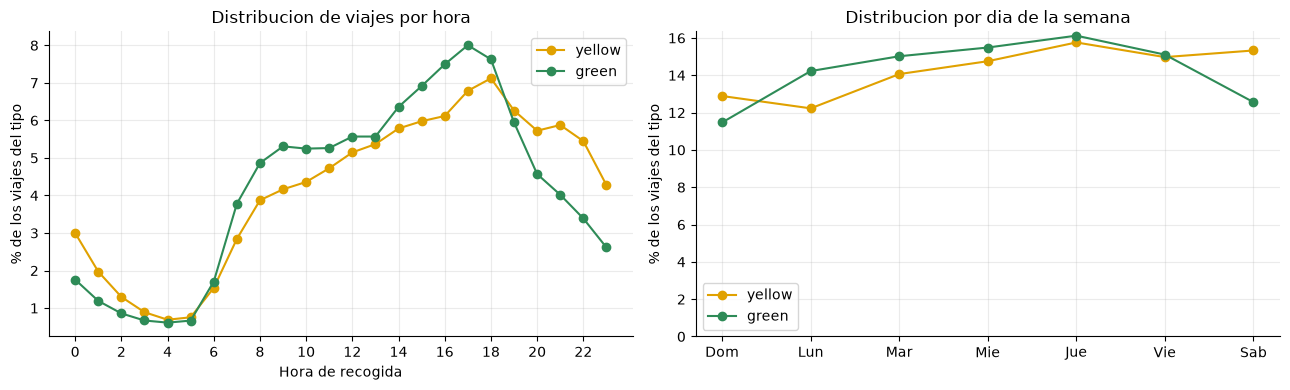

In [5]:
horas = q("SELECT taxi_type, hour(pickup_datetime) AS hora, count(*) AS viajes FROM trips WHERE year(pickup_datetime) = year GROUP BY ALL ORDER BY ALL")
horas["pct"] = horas.viajes / horas.groupby("taxi_type").viajes.transform("sum") * 100
dias = q("SELECT taxi_type, dayofweek(pickup_datetime) AS dia, count(*) AS viajes FROM trips WHERE year(pickup_datetime) = year GROUP BY ALL ORDER BY ALL")
dias["pct"] = dias.viajes / dias.groupby("taxi_type").viajes.transform("sum") * 100
nombres = ["Dom", "Lun", "Mar", "Mie", "Jue", "Vie", "Sab"]

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4))
for tipo in ("yellow", "green"):
    d = horas[horas.taxi_type == tipo]; a.plot(d.hora, d.pct, marker="o", color=COLOR[tipo], label=tipo)
    d = dias[dias.taxi_type == tipo]; b.plot(d.dia, d.pct, marker="o", color=COLOR[tipo], label=tipo)
a.set_title("Distribucion de viajes por hora"); a.set_xlabel("Hora de recogida"); a.set_ylabel("% de los viajes del tipo"); a.set_xticks(range(0, 24, 2)); a.legend()
b.set_title("Distribucion por dia de la semana"); b.set_xticks(range(7), nombres); b.set_ylabel("% de los viajes del tipo"); b.set_ylim(bottom=0); b.legend()
plt.tight_layout(); plt.show()

**Interpretacion.** Ambos servicios tienen un minimo entre las 3 y las 5 h y un maximo en la tarde: yellow alcanza su pico a las 18 h (17 y 19 h le siguen) y green a las 17 h (8.0 % de sus viajes).
Green concentra mas actividad en horario laboral y menos de madrugada; yellow mantiene mas viajes nocturnos (0 h = 3.0 %).
Por dia, el jueves es el de mayor actividad en ambos (15.8 % yellow, 16.1 % green) y el domingo y el lunes los mas bajos en yellow. El sabado muestra la diferencia entre servicios: yellow se mantiene alto (15.3 %) y green baja a 12.6 %.

## P6. Formas de pago

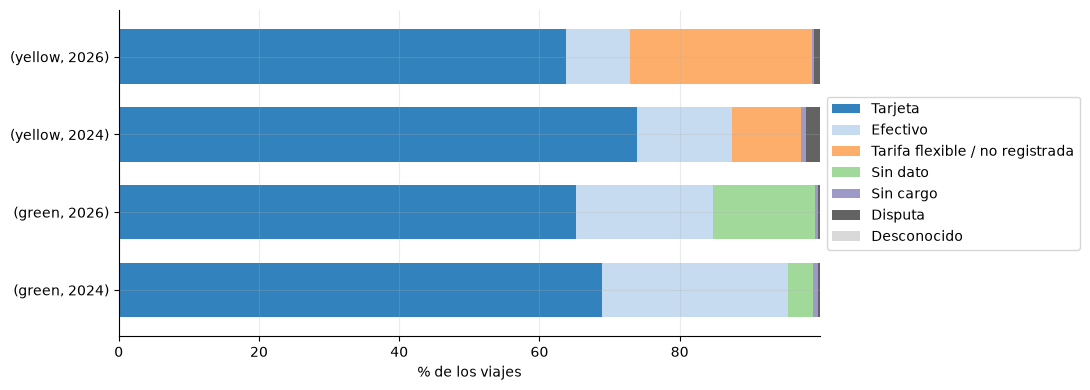

tipo_pago       Tarjeta  Efectivo  Tarifa flexible / no registrada  Sin dato  \
taxi_type year                                                                 
green     2024    68.87     26.51                             0.00      3.68   
          2026    65.25     19.55                             0.00     14.47   
yellow    2024    73.97     13.46                             9.94      0.00   
          2026    63.77      9.12                            25.98      0.00   

tipo_pago       Sin cargo  Disputa  Desconocido  
taxi_type year                                   
green     2024       0.70     0.24          0.0  
          2026       0.50     0.22          0.0  
yellow    2024       0.71     1.93          0.0  
          2026       0.33     0.81          0.0

In [6]:
pagos = q("SELECT taxi_type, year, coalesce(payment_type::VARCHAR, 'sin dato') AS tipo_pago, count(*) AS viajes FROM trips GROUP BY ALL")
pagos["pct"] = pagos.viajes / pagos.groupby(["taxi_type", "year"]).viajes.transform("sum") * 100
etiquetas = {"1": "Tarjeta", "2": "Efectivo", "0": "Tarifa flexible / no registrada", "sin dato": "Sin dato", "3": "Sin cargo", "4": "Disputa", "5": "Desconocido"}
tabla = pagos.pivot_table(index=["taxi_type", "year"], columns="tipo_pago", values="pct", fill_value=0).rename(columns=etiquetas)
orden = [c for c in ["Tarjeta", "Efectivo", "Tarifa flexible / no registrada", "Sin dato", "Sin cargo", "Disputa", "Desconocido"] if c in tabla.columns]
tabla = tabla[orden]
tabla.plot(kind="barh", stacked=True, figsize=(11, 4), colormap="tab20c", width=0.7)
plt.xlabel("% de los viajes"); plt.ylabel(""); plt.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout(); plt.show()
tabla.round(2)

In [7]:
q('''
SELECT taxi_type, year,
       round(avg(fare_amount), 2) AS tarifa_prom,
       round(avg(tip_amount) FILTER (WHERE payment_type = 1), 2) AS propina_prom_tarjeta,
       round(avg(tip_amount), 2) AS propina_prom_todos
FROM trips WHERE month <= 8 AND trip_distance > 0 AND trip_distance < 100 AND fare_amount > 0 AND fare_amount < 1000
  AND duration_minutes > 0 AND duration_minutes < 1440
GROUP BY ALL ORDER BY ALL''')

,taxi_type,year,tarifa_prom,propina_prom_tarjeta,propina_prom_todos
0,green,2024,17.88,3.61,2.59
1,green,2026,17.16,3.81,2.65
2,yellow,2024,19.54,4.30,3.34
3,yellow,2026,21.30,4.26,2.88


**Interpretacion.** La tarjeta es la forma de pago principal (74 % de los viajes yellow en 2024). Entre 2024 y 2026 la mezcla cambia mucho: en yellow la categoria `0` (tarifa flexible / no registrada) pasa de
9.9 % a 26.0 % y la tarjeta baja a 63.8 %; el efectivo cae de 13.5 % a 9.1 %. En green, los viajes sin dato de pago suben de 3.7 % a 14.5 %. Como el efectivo y la categoria 0 casi no registran propina, la
propina promedio de yellow cae de 3.34 a 2.88 USD, pero **la propina promedio con tarjeta se mantiene (4.30 vs 4.26)**: lo que cambio es la mezcla de pagos, no el comportamiento de los pasajeros.

## P7. Valores atipicos e inconsistencias

,taxi_type,year,viajes,distancia_cero,distancia_mayor_100,monto_negativo,monto_mayor_1000,duracion_no_positiva,duracion_mayor_24h,fecha_fuera_del_anio
0,green,2024,660218,34574.0,235.0,2174.0,1.0,662.0,0.0,20.0
1,green,2026,337114,12212.0,72.0,1023.0,1.0,234.0,4.0,14.0
2,yellow,2024,41169720,776305.0,1613.0,609344.0,43.0,13510.0,230.0,56.0
3,yellow,2026,29703355,952231.0,1223.0,161835.0,49.0,371683.0,263.0,17.0


,taxi_type,max_distancia,min_total,max_total,recogida_mas_antigua
0,yellow,398608.62,-2560.2,335550.94,2001-01-01 09:23:58
1,green,233972.43,-501.5,1678.20,2008-12-31 00:00:00


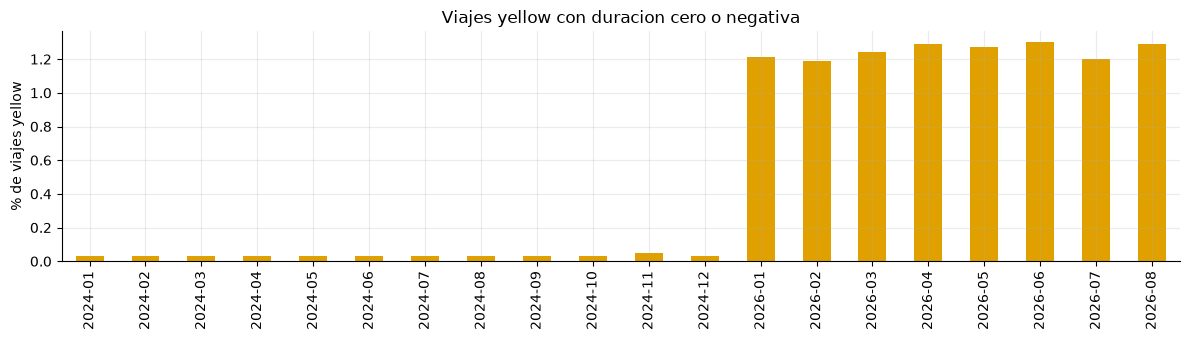

,vendor_id,viajes,duracion_no_positiva
0,1,5467071,4301.0
1,2,23809774,258.0
2,6,59390,4.0
3,7,367120,367120.0


In [8]:
atipicos = q('''
SELECT taxi_type, year, count(*) AS viajes,
       count_if(trip_distance = 0) AS distancia_cero, count_if(trip_distance > 100) AS distancia_mayor_100,
       count_if(total_amount < 0) AS monto_negativo, count_if(total_amount > 1000) AS monto_mayor_1000,
       count_if(duration_minutes <= 0) AS duracion_no_positiva, count_if(duration_minutes > 1440) AS duracion_mayor_24h,
       count_if(year(pickup_datetime) <> year) AS fecha_fuera_del_anio
FROM trips GROUP BY ALL ORDER BY ALL''')
display(atipicos)
extremos = q("SELECT taxi_type, max(trip_distance) AS max_distancia, min(total_amount) AS min_total, max(total_amount) AS max_total, min(pickup_datetime) AS recogida_mas_antigua FROM trips GROUP BY ALL")
display(extremos)

duracion = q("SELECT year, month, round(100.0 * count_if(duration_minutes <= 0) / count(*), 2) AS pct FROM trips WHERE taxi_type = 'yellow' GROUP BY ALL ORDER BY ALL")
duracion["periodo"] = duracion.year.astype(str) + "-" + duracion.month.astype(str).str.zfill(2)
duracion.plot(x="periodo", y="pct", kind="bar", legend=False, color=COLOR["yellow"], figsize=(12, 3.5))
plt.ylabel("% de viajes yellow"); plt.title("Viajes yellow con duracion cero o negativa"); plt.xlabel(""); plt.tight_layout(); plt.show()

q("SELECT vendor_id, count(*) AS viajes, count_if(duration_minutes <= 0) AS duracion_no_positiva FROM trips WHERE taxi_type = 'yellow' AND year = 2026 GROUP BY ALL ORDER BY ALL")

**Interpretacion.** Los datos no vienen limpios: hay distancias de hasta cientos de miles de millas, montos totales desde -2,560 hasta +335,550 USD y recogidas con fechas de 2001 a 2008
(en realidad son errores de reloj del taxi). Las distancias cero (776 mil en 2024, 952 mil en 2026 en yellow) y los montos negativos (reembolsos o cancelaciones: 609 mil en 2024, 162 mil en 2026) son comunes.
Lo mas llamativo es que **las duraciones no positivas pasan de 13.5 mil viajes yellow en 2024 a 371.7 mil en 2026**, de forma constante en todos los meses de 2026 (~1.2 %): el vendor_id 7, que
aparece solo en 2026, registra 367,120 viajes y **todos** con duracion cero. Es un problema de captura de ese proveedor y no un cambio real, y justifica filtrar por duracion antes de calcular promedios.

## P8. Hallazgos

1. **El crecimiento de yellow y la caida de green son opuestos.** Entre enero y agosto, yellow crece 12.6 % de 2024 a 2026 y green cae 24.0 %.
2. **La mezcla de pagos cambio fuertemente y distorsiona las propinas.** La categoria de pago 0 pasa de 9.9 % a 26.0 % de los viajes yellow; la propina promedio general baja 14 % (3.34 a 2.88 USD)
   pero con tarjeta se mantiene (4.30 vs 4.26). Comparar propinas sin separar la forma de pago llevaria a una conclusion equivocada.
3. **Yellow y green son servicios distintos.** Green es 1.4 % del volumen, opera mas rapido (15.6 vs 11.2 mph), concentra sus viajes en East Harlem, tiene su pico a las 17 h y pierde actividad el fin de semana, mientras que yellow
   (aeropuerto y Manhattan central) mantiene un sabado fuerte y mas viajes de madrugada.
4. **Calidad de datos: un proveedor nuevo en 2026 introduce duraciones de cero.** El vendor_id 7 explica el 98.8 % de las duraciones no positivas de yellow en 2026 (371.7 mil viajes), 27 veces mas que en 2024.
5. **Los promedios enganan:** la mediana de la tarifa yellow (14.2 a 15.6 USD) es 25 a 30 % menor que el promedio por la cola de viajes largos.